In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv('advertising.csv')
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
data.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


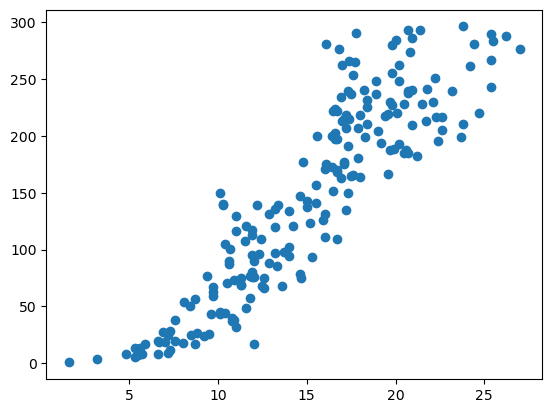

In [4]:
plt.scatter(x=data.Sales, y=data.TV)

<Axes: xlabel='Sales', ylabel='TV'>

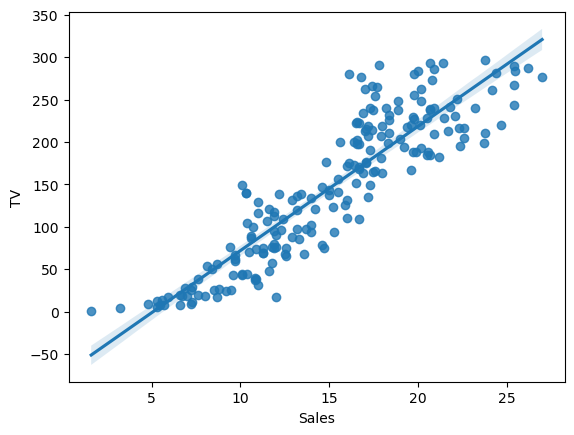

In [5]:
sns.regplot(x=data.Sales, y=data.TV)

<Axes: xlabel='Sales', ylabel='Newspaper'>

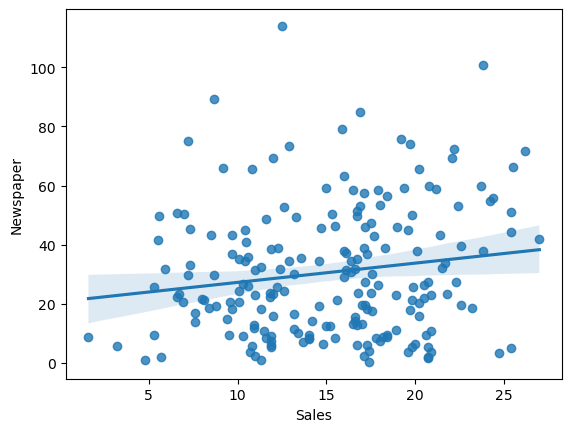

In [6]:
sns.regplot(x=data.Sales, y=data.Newspaper)

<Axes: xlabel='Sales', ylabel='Radio'>

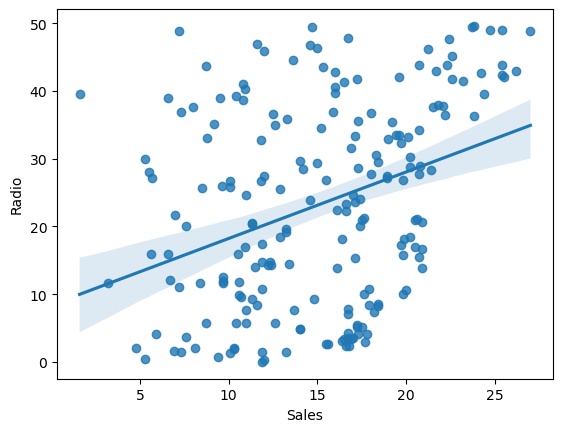

In [7]:
sns.regplot(x=data.Sales, y=data.Radio)

In [8]:
x = data.drop('Sales',axis=1)

In [9]:
y = data.Sales

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.25, random_state=1321)

In [11]:
from sklearn.linear_model import LinearRegression
mlr = LinearRegression()
mlr.fit(x_train,y_train)

LinearRegression()

In [12]:
print("Coffiecent:",mlr.coef_)
print("Intercept:", mlr.intercept_)

Coffiecent: [ 0.05605743  0.10340705 -0.00140951]
Intercept: 4.518689883597048


In [13]:
y_pred_train = mlr.predict(x_train)

In [14]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
print("Absoulte Error",mean_absolute_error(y_train,y_pred_train))
print("Squared Error",root_mean_squared_error(y_train,y_pred_train))
print("R2 Score",r2_score(y_train,y_pred_train))

Absoulte Error 1.2488549127544615
Squared Error 1.6121983984617991
R2 Score 0.9098564520877563


In [15]:
print('Variance Scroe%2.f' % mlr.score(x_train,y_train))

Variance Scroe 1


In [16]:
y_pred_test = mlr.predict(x_test)

In [17]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
print("Absoulte Error",mean_absolute_error(y_test,y_pred_test))
print("Squared Error",root_mean_squared_error(y_test,y_pred_test))
print("R2 Score",r2_score(y_test,y_pred_test))

Absoulte Error 1.261441106286129
Squared Error 1.766364170954173
R2 Score 0.8723441443650843


In [18]:
print('Variance Score %2.f' %mlr.score(x_test,y_test))

Variance Score  1


In [19]:
def predication_sale(tv,radio,newspaper):
    recored = pd.DataFrame({'TV':[tv],'Radio':[radio],'Newspaper':[newspaper]})
    print(recored)
    return mlr.predict(recored)

In [21]:
tv = float(input('How many dollar to invest in TV:'))
radio = float(input('How many dollar to invest in Radio:'))
newspaper = float(input('How many dollar to invest in Newspaper:'))
print(f"The except dollar sales in {(predication_sale(tv,radio,newspaper)[0])} ")

How many dollar to invest in TV: 123
How many dollar to invest in Radio: 321
How many dollar to invest in Newspaper: 456


      TV  Radio  Newspaper
0  123.0  321.0      456.0
The except dollar sales in 43.96468104660613 


In [22]:
import pickle 
pickle.dump(mlr,open('Multiple_Linear_Regression.sav','wb'))